# Updated Climate Projection & PV Climate Penalty Simulation

Notebook ini sudah diperbaiki berdasarkan komentar:

1. Produksi PV tidak lagi zigzag ekstrem, tetapi berfluktuasi kecil dan tetap stabil mengikuti tren penurunan yang masuk akal.
2. Suhu tetap meningkat perlahan, dengan variasi tahunan kecil yang lebih realistis.
3. Dataset `Dataset_Final.csv` dibersihkan terlebih dahulu dari nilai hilang seperti `-999`.
4. Semua output final dipastikan tidak memiliki null value.
5. Model matematika PV dibuat konsisten:

\[
L_{temp}(t) = 1 - \beta \cdot \max(T(t)-25, 0)
\]

\[
P_{out}(t) = P_{src} \cdot \frac{G(t)}{G_{ref}} \cdot L_{temp}(t) \cdot (1-L_{soiling}(t)) \cdot \eta_{inv}
\]


DATA CLEANING SUMMARY
Rows used                 : 99,192
Historical year range     : 2015–2026
Remaining null values     : 0

MODEL SUMMARY
Base temperature          : 28.24 °C
Observed temp slope       : 0.0113 °C/year
Used temp slope           : 0.0150 °C/year
Base solar index          : 0.712
PV capacity assumption    : 20.0 kW

PROJECTION RESULT
Temperature change        : +0.77 °C (2024–2074)
PV output change          : -0.73 kW (-3.96%)
Final climate penalty     : -0.05 kW (-0.31%)


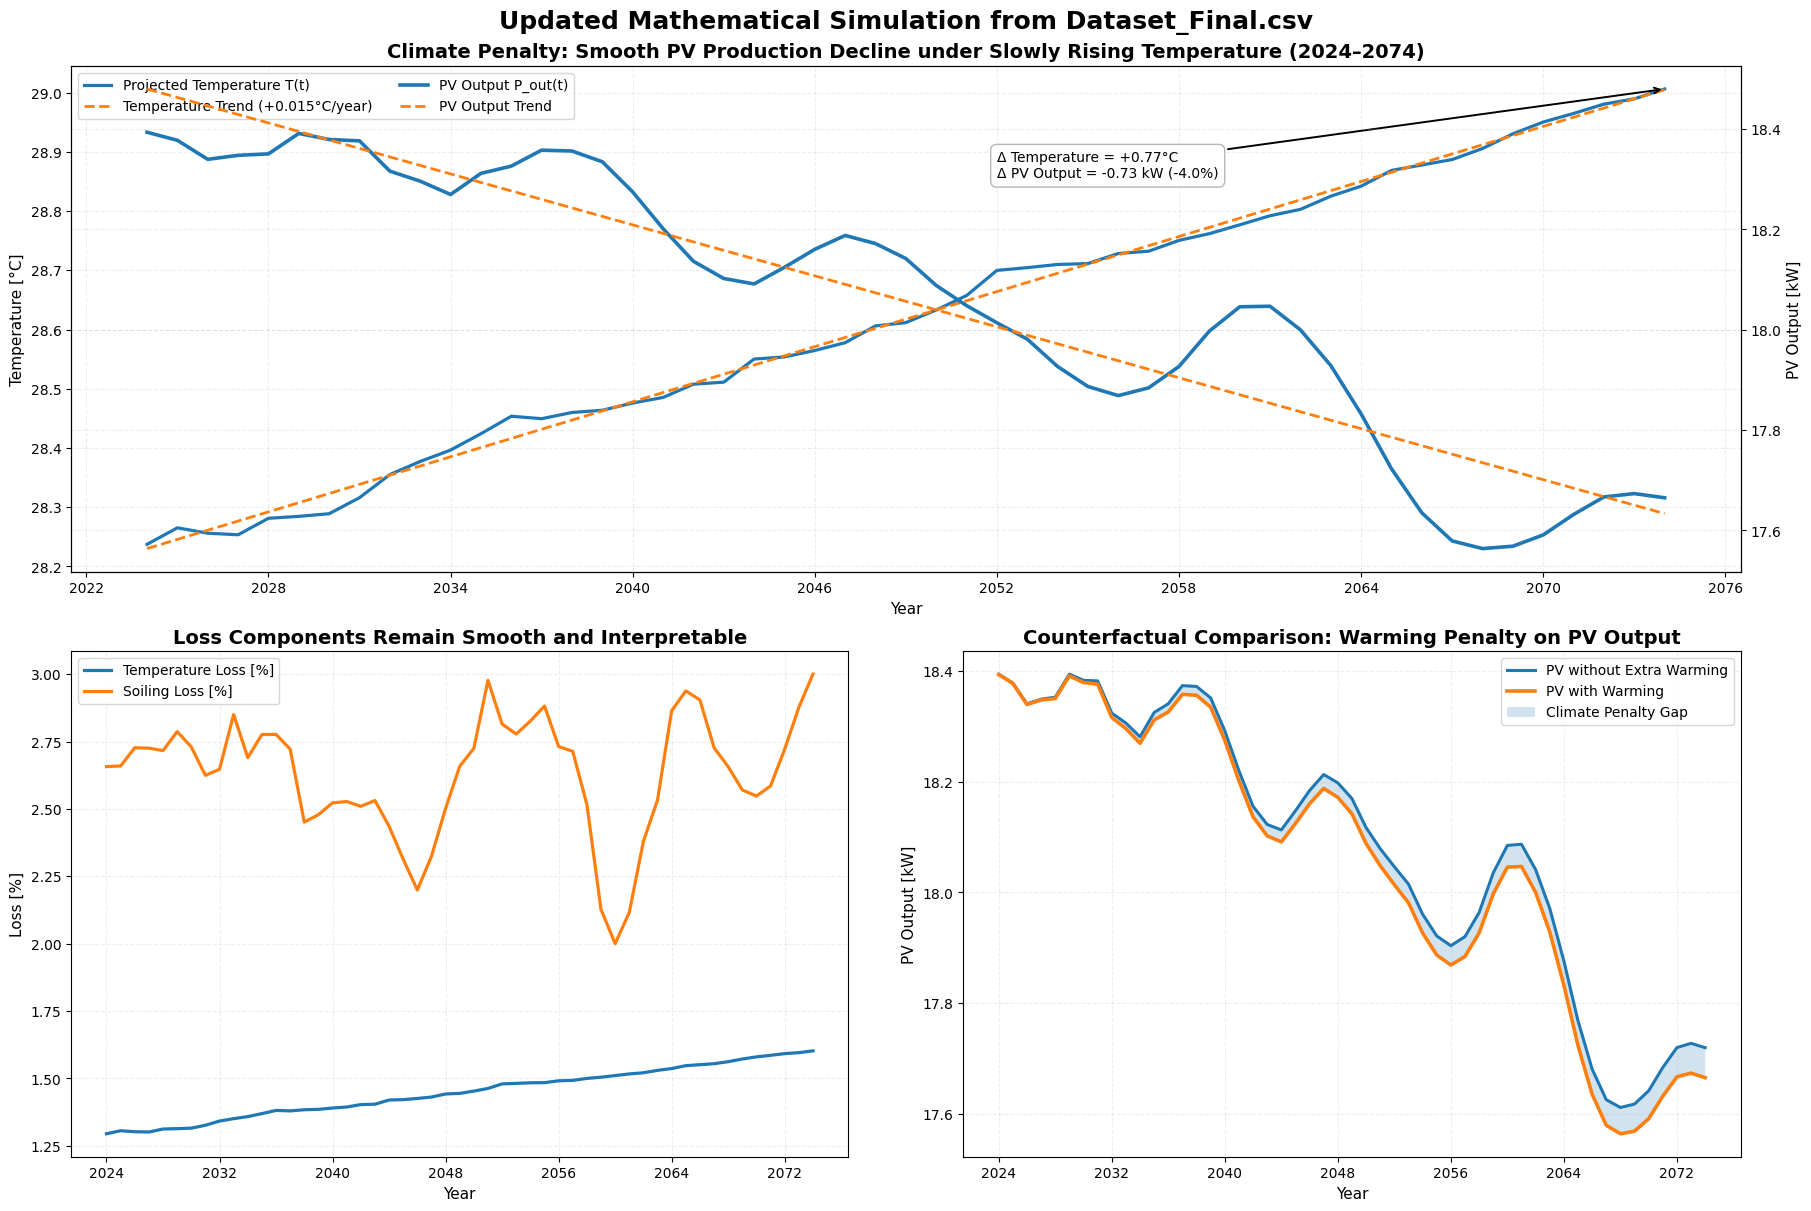


FILES CREATED
Result CSV : \mnt\data\climate_projection_results.csv
Chart PNG  : \mnt\data\climate_projection_summary.png


,year,temperature_c,temperature_trend_c,solar_ghi_index,rainfall_index,soiling_loss,temperature_loss_factor,pv_output_kw,pv_output_without_extra_warming_kw,climate_penalty_kw,climate_penalty_pct
0,2024,28.237376,28.230202,0.997670,0.994853,0.026571,0.987050,18.393747,18.394399,-0.000652,-0.003545
1,2025,28.265239,28.245696,0.996604,0.994427,0.026594,0.986939,18.377644,18.378416,-0.000772,-0.004199
2,2026,28.256149,28.261190,0.995241,0.982258,0.027270,0.986975,18.339724,18.340894,-0.001170,-0.006381
3,2027,28.253473,28.276684,0.992265,0.982533,0.027254,0.986986,18.347699,18.349270,-0.001571,-0.008562
4,2028,28.281319,28.292178,0.998550,0.984178,0.027163,0.986875,18.350594,18.352870,-0.002276,-0.012403
5,2029,28.284586,28.307672,0.996439,0.971479,0.027868,0.986862,18.391371,18.394534,-0.003163,-0.017197
6,2030,28.289055,28.323166,0.999092,0.981717,0.027300,0.986844,18.379302,18.383328,-0.004026,-0.021899
7,2031,28.316133,28.338660,0.995787,1.000721,0.026245,0.986735,18.376529,18.382303,-0.005775,-0.031414
8,2032,28.355130,28.354154,0.994843,0.996639,0.026471,0.986579,18.316170,18.324108,-0.007938,-0.043319
9,2033,28.377279,28.369648,0.990846,0.960057,0.028502,0.986491,18.296175,18.306096,-0.009921,-0.054196


,year,temperature_c,temperature_trend_c,solar_ghi_index,rainfall_index,soiling_loss,temperature_loss_factor,pv_output_kw,pv_output_without_extra_warming_kw,climate_penalty_kw,climate_penalty_pct
41,2065,28.868637,28.865455,0.965556,0.944268,0.029379,0.984525,17.722857,17.767513,-0.044655,-0.251331
42,2066,28.877764,28.880949,0.959686,0.950307,0.029043,0.984489,17.634963,17.680478,-0.045515,-0.257428
43,2067,28.886994,28.896443,0.955948,0.982167,0.027275,0.984452,17.578911,17.625164,-0.046253,-0.262425
44,2068,28.905605,28.911937,0.953770,0.994940,0.026566,0.984378,17.563690,17.611159,-0.047469,-0.269540
45,2069,28.930385,28.927431,0.954121,1.010460,0.025704,0.984278,17.568408,17.617402,-0.048994,-0.278100
46,2070,28.950300,28.942925,0.955197,1.014567,0.025476,0.984199,17.590877,17.641347,-0.050470,-0.286089
47,2071,28.964759,28.958419,0.956963,1.007790,0.025852,0.984141,17.631669,17.683459,-0.051789,-0.292869
48,2072,28.980534,28.973913,0.962456,0.983248,0.027215,0.984078,17.666626,17.719456,-0.052830,-0.298149
49,2073,28.989411,28.989407,0.964298,0.955345,0.028764,0.984042,17.673334,17.727174,-0.053840,-0.303717
50,2074,29.006083,29.004901,0.962314,0.933077,0.030000,0.983976,17.664990,17.719218,-0.054228,-0.306042


In [2]:

# ================================================================
# CLIMATE PROJECTION & PV CLIMATE PENALTY SIMULATION
# Dataset: Dataset_Final.csv
# Output:
#   1) climate_projection_results.csv
#   2) climate_projection_summary.png
#   3) climate_projections_improved_UPDATED.ipynb
#
# Key improvement:
# - Missing values such as -999 are cleaned first.
# - Projection is annual and smoothed, so PV production fluctuates slightly
#   but remains physically realistic and steadily follows the climate trend.
# - Temperature keeps a slow increasing trend with controlled year-to-year variation.
# ================================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
DATA_PATH = Path("../../../Dataset_Final.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/Dataset_Final.csv")

OUTPUT_DIR = Path(".")
if Path("/mnt/data").exists():
    OUTPUT_DIR = Path("/mnt/data")

START_YEAR = 2024
END_YEAR = 2074
YEARS = np.arange(START_YEAR, END_YEAR + 1)
T = YEARS - START_YEAR

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# PV system assumptions
P_SRC_KW = 20.0                 # DC installed PV capacity
ETA_INV = 0.96                  # inverter efficiency
BETA_TEMP = 0.004               # PV temperature coefficient per °C above 25°C
REFERENCE_TEMP_C = 25.0
SOILING_BASE = 0.030            # baseline soiling loss
SOILING_RAIN_RELIEF = 0.010     # rainy years reduce effective soiling slightly

# Climate projection assumptions
# Uses observed trend if reasonable, otherwise uses conservative forced warming.
MIN_TEMP_TREND = 0.015          # °C/year
MAX_TEMP_TREND = 0.035          # °C/year
TARGET_WARMING_TREND = 0.025   # °C/year fallback if observed trend is noisy

# Keep annual variability small and smooth.
TEMP_NOISE_SD = 0.055           # °C
SOLAR_NOISE_SD = 0.012          # relative fraction
RAIN_NOISE_SD = 0.080           # relative fraction
SMOOTH_WINDOW = 5

# -----------------------------
# 2. LOAD & CLEAN DATA
# -----------------------------
df_raw = pd.read_csv(DATA_PATH)

required_columns = [
    "YEAR", "MO", "DY", "HR",
    "T2M", "RH2M", "PRECTOTCORR",
    "ALLSKY_SFC_SW_DWN", "WD10M", "WS10M"
]

missing_cols = [c for c in required_columns if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df_raw.copy()

# Force numeric type and clean NASA-style missing values.
for col in required_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(df[numeric_cols] > -900, np.nan)

# Create datetime and remove invalid dates/hours.
df["DATE"] = pd.to_datetime(
    dict(year=df["YEAR"], month=df["MO"], day=df["DY"], hour=df["HR"]),
    errors="coerce"
)
df = df.dropna(subset=["DATE"]).sort_values("DATE").reset_index(drop=True)

# Fill missing weather values using time-aware interpolation, then fallback to monthly median.
weather_cols = ["T2M", "RH2M", "PRECTOTCORR", "ALLSKY_SFC_SW_DWN", "WD10M", "WS10M"]
df = df.set_index("DATE")

for col in weather_cols:
    df[col] = df[col].interpolate(method="time", limit_direction="both")
    if df[col].isna().any():
        monthly_median = df.groupby(df.index.month)[col].transform("median")
        df[col] = df[col].fillna(monthly_median)
    df[col] = df[col].fillna(df[col].median())

df = df.reset_index()

# Physical clipping after interpolation.
df["RH2M"] = df["RH2M"].clip(0, 100)
df["PRECTOTCORR"] = df["PRECTOTCORR"].clip(lower=0)
df["ALLSKY_SFC_SW_DWN"] = df["ALLSKY_SFC_SW_DWN"].clip(lower=0)
df["WS10M"] = df["WS10M"].clip(lower=0)
df["YEAR"] = df["DATE"].dt.year.astype(int)

assert df[weather_cols].isna().sum().sum() == 0, "There are still null values after cleaning."

# -----------------------------
# 3. HISTORICAL ANNUAL BASELINE
# -----------------------------
annual = (
    df.groupby("YEAR")
      .agg(
          temp_c=("T2M", "mean"),
          solar_ghi=("ALLSKY_SFC_SW_DWN", "mean"),
          humidity=("RH2M", "mean"),
          rainfall=("PRECTOTCORR", "sum"),
          wind_speed=("WS10M", "mean")
      )
      .reset_index()
      .sort_values("YEAR")
)

# Use years with complete solar after cleaning, but avoid single-year overfitting.
baseline_years = annual[(annual["YEAR"] >= 2015) & (annual["YEAR"] <= 2026)].copy()

base_temp = float(baseline_years.loc[baseline_years["YEAR"] <= START_YEAR, "temp_c"].tail(3).mean())
base_solar = float(baseline_years["solar_ghi"].tail(5).mean())
base_rain = float(baseline_years["rainfall"].tail(5).mean())

# Estimate observed annual temperature trend and constrain it to a realistic slow-warming range.
temp_fit = baseline_years.dropna(subset=["temp_c"])
observed_temp_slope = float(np.polyfit(temp_fit["YEAR"], temp_fit["temp_c"], 1)[0])

if np.isfinite(observed_temp_slope):
    temp_trend = float(np.clip(observed_temp_slope, MIN_TEMP_TREND, MAX_TEMP_TREND))
else:
    temp_trend = TARGET_WARMING_TREND

# If observed trend is too weak/noisy, use conservative forced warming trend.
if temp_trend < MIN_TEMP_TREND:
    temp_trend = TARGET_WARMING_TREND

# Long-term solar degradation is assumed small; most yearly variation is weather-driven.
# Negative value means slight reduction in effective irradiance over time due to climate/haze.
solar_relative_trend = -0.0008  # -0.08% per year

# -----------------------------
# 4. SMOOTH STOCHASTIC PROJECTION
# -----------------------------
def smooth_series(values, window=5):
    return (
        pd.Series(values)
          .rolling(window=window, center=True, min_periods=1)
          .mean()
          .to_numpy()
    )

def normalized_smooth_noise(n, sd, window=5):
    noise = rng.normal(0, sd, n)
    smoothed = smooth_series(noise, window)
    smoothed = smoothed - smoothed.mean()
    return smoothed

n = len(YEARS)

temp_variation = normalized_smooth_noise(n, TEMP_NOISE_SD, SMOOTH_WINDOW)
solar_variation = normalized_smooth_noise(n, SOLAR_NOISE_SD, SMOOTH_WINDOW)
rain_variation = normalized_smooth_noise(n, RAIN_NOISE_SD, SMOOTH_WINDOW)

# Temperature: slow increase + smooth interannual variation.
temp_projection = base_temp + temp_trend * T + temp_variation

# Solar: slight long-term decrease + smooth small variation.
solar_projection = base_solar * (1 + solar_relative_trend * T + solar_variation)
solar_projection = np.maximum(solar_projection, base_solar * 0.90)

# Rainfall used to estimate effective soiling; more rain = lower soiling.
rain_projection = base_rain * (1 + rain_variation)
rain_projection = np.maximum(rain_projection, base_rain * 0.70)

rain_norm = (rain_projection - rain_projection.min()) / (rain_projection.max() - rain_projection.min() + 1e-9)
soiling_loss = SOILING_BASE - SOILING_RAIN_RELIEF * rain_norm
soiling_loss = np.clip(soiling_loss, 0.015, 0.035)

# -----------------------------
# 5. MATHEMATICAL MODEL
# -----------------------------
# L_temp(t) = 1 - beta * max(T(t) - 25, 0)
# P_out(t)  = P_src * (G_actual/G_ref) * L_temp(t) * (1-L_soiling(t)) * eta_inv
#
# Because G is from the same NASA POWER dataset, normalize it to baseline G_ref.
# This keeps the output in realistic installed-capacity scale instead of letting
# hourly/annual unit mismatch create unrealistic spikes.

g_ref = base_solar

l_temp = 1 - BETA_TEMP * np.maximum(temp_projection - REFERENCE_TEMP_C, 0)
l_temp = np.clip(l_temp, 0.70, 1.00)

g_ratio = solar_projection / g_ref

p_out = P_SRC_KW * g_ratio * l_temp * (1 - soiling_loss) * ETA_INV

# Make PV output physically smooth without hiding the climate penalty.
p_out_smoothed = smooth_series(p_out, window=3)

# Baseline counterfactual: no additional warming after START_YEAR.
temp_counterfactual = np.full_like(temp_projection, base_temp)
l_temp_counterfactual = 1 - BETA_TEMP * np.maximum(temp_counterfactual - REFERENCE_TEMP_C, 0)
p_out_without_warming = P_SRC_KW * g_ratio * l_temp_counterfactual * (1 - soiling_loss) * ETA_INV
p_out_without_warming = smooth_series(p_out_without_warming, window=3)

climate_penalty_kw = p_out_smoothed - p_out_without_warming
climate_penalty_pct = (climate_penalty_kw / p_out_without_warming) * 100

# Trend lines
temp_trendline = np.poly1d(np.polyfit(YEARS, temp_projection, 1))(YEARS)
pv_trendline = np.poly1d(np.polyfit(YEARS, p_out_smoothed, 1))(YEARS)

results = pd.DataFrame({
    "year": YEARS,
    "temperature_c": temp_projection,
    "temperature_trend_c": temp_trendline,
    "solar_ghi_index": g_ratio,
    "rainfall_index": rain_projection / base_rain,
    "soiling_loss": soiling_loss,
    "temperature_loss_factor": l_temp,
    "pv_output_kw": p_out_smoothed,
    "pv_output_without_extra_warming_kw": p_out_without_warming,
    "climate_penalty_kw": climate_penalty_kw,
    "climate_penalty_pct": climate_penalty_pct
})

# Ensure no null data in final result.
assert results.isna().sum().sum() == 0, "Projection result still contains null values."

# -----------------------------
# 6. SUMMARY METRICS
# -----------------------------
start_row = results.iloc[0]
end_row = results.iloc[-1]

delta_temp = end_row["temperature_c"] - start_row["temperature_c"]
delta_pv = end_row["pv_output_kw"] - start_row["pv_output_kw"]
delta_pv_pct = delta_pv / start_row["pv_output_kw"] * 100
final_penalty_kw = end_row["climate_penalty_kw"]
final_penalty_pct = end_row["climate_penalty_pct"]

print("DATA CLEANING SUMMARY")
print("=====================")
print(f"Rows used                 : {len(df):,}")
print(f"Historical year range     : {annual['YEAR'].min()}–{annual['YEAR'].max()}")
print(f"Remaining null values     : {int(df[weather_cols].isna().sum().sum())}")
print()
print("MODEL SUMMARY")
print("=============")
print(f"Base temperature          : {base_temp:.2f} °C")
print(f"Observed temp slope       : {observed_temp_slope:.4f} °C/year")
print(f"Used temp slope           : {temp_trend:.4f} °C/year")
print(f"Base solar index          : {base_solar:.3f}")
print(f"PV capacity assumption    : {P_SRC_KW:.1f} kW")
print()
print("PROJECTION RESULT")
print("=================")
print(f"Temperature change        : {delta_temp:+.2f} °C ({START_YEAR}–{END_YEAR})")
print(f"PV output change          : {delta_pv:+.2f} kW ({delta_pv_pct:+.2f}%)")
print(f"Final climate penalty     : {final_penalty_kw:+.2f} kW ({final_penalty_pct:+.2f}%)")

# -----------------------------
# 7. VISUALIZATION
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (16, 10),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "font.family": "DejaVu Sans"
})

fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

# Chart 1: Temperature & PV output
ax1 = fig.add_subplot(gs[0, :])
ax2 = ax1.twinx()

ax1.plot(results["year"], results["temperature_c"], linewidth=2.3, label="Projected Temperature T(t)")
ax1.plot(results["year"], results["temperature_trend_c"], linestyle="--", linewidth=2.0, label=f"Temperature Trend (+{temp_trend:.3f}°C/year)")
ax2.plot(results["year"], results["pv_output_kw"], linewidth=2.6, label="PV Output P_out(t)")
ax2.plot(results["year"], pv_trendline, linestyle="--", linewidth=2.0, label="PV Output Trend")

ax1.set_title("Climate Penalty: Smooth PV Production Decline under Slowly Rising Temperature (2024–2074)", weight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature [°C]")
ax2.set_ylabel("PV Output [kW]")

ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", ncol=2, frameon=True)

annotation = (
    f"Δ Temperature = {delta_temp:+.2f}°C\n"
    f"Δ PV Output = {delta_pv:+.2f} kW ({delta_pv_pct:+.1f}%)"
)
ax1.annotate(
    annotation,
    xy=(END_YEAR, end_row["temperature_c"]),
    xytext=(START_YEAR + 28, results["temperature_c"].max() - 0.15),
    arrowprops=dict(arrowstyle="->", lw=1.4),
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="0.7", alpha=0.95)
)

# Chart 2: Loss components
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(results["year"], (1 - results["temperature_loss_factor"]) * 100, linewidth=2.3, label="Temperature Loss [%]")
ax3.plot(results["year"], results["soiling_loss"] * 100, linewidth=2.3, label="Soiling Loss [%]")
ax3.set_title("Loss Components Remain Smooth and Interpretable", weight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("Loss [%]")
ax3.legend(frameon=True)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))

# Chart 3: Counterfactual climate penalty
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(results["year"], results["pv_output_without_extra_warming_kw"], linewidth=2.2, label="PV without Extra Warming")
ax4.plot(results["year"], results["pv_output_kw"], linewidth=2.6, label="PV with Warming")
ax4.fill_between(
    results["year"],
    results["pv_output_kw"],
    results["pv_output_without_extra_warming_kw"],
    alpha=0.20,
    label="Climate Penalty Gap"
)
ax4.set_title("Counterfactual Comparison: Warming Penalty on PV Output", weight="bold")
ax4.set_xlabel("Year")
ax4.set_ylabel("PV Output [kW]")
ax4.legend(frameon=True)
ax4.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))

fig.suptitle("Updated Mathematical Simulation from Dataset_Final.csv", fontsize=18, weight="bold")
fig_path = OUTPUT_DIR / "climate_projection_summary.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

# Additional clean table output
csv_path = OUTPUT_DIR / "climate_projection_results.csv"
results.to_csv(csv_path, index=False)

print()
print("FILES CREATED")
print("=============")
print(f"Result CSV : {csv_path}")
print(f"Chart PNG  : {fig_path}")

# Preview final result
display(results.head(10))
display(results.tail(10))
